In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
df_full = pd.read_csv('software_defect_prediction_dataset.csv')

In [4]:
display(df_full.head())

,lines_of_code,cyclomatic_complexity,num_functions,num_classes,comment_density,code_churn,developer_experience_years,num_developers,commit_frequency,bug_fix_commits,...,avg_function_length,depth_of_inheritance,response_for_class,coupling_between_objects,lack_of_cohesion,build_failures,static_analysis_warnings,security_vulnerabilities,performance_issues,defect
0,910,12,7,79,0.59,539,19,4,23,7,...,70,1,54,27,0.06,3,20,31,21,1
1,3822,9,197,72,0.30,584,8,8,126,153,...,180,5,73,23,0.39,9,154,38,29,1
2,3142,20,99,92,0.11,593,0,6,272,177,...,152,5,9,31,0.08,7,425,22,6,1
3,516,39,52,79,0.18,81,12,14,16,0,...,159,9,23,12,0.44,2,339,24,12,1
4,4476,27,162,75,0.21,918,14,1,164,109,...,169,2,84,9,0.41,3,111,19,2,1


In [5]:
print(f"Dataset shape: {df_full.shape}")

Dataset shape: (60000, 23)


In [6]:
display(df_full.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   lines_of_code               60000 non-null  int64  
 1   cyclomatic_complexity       60000 non-null  int64  
 2   num_functions               60000 non-null  int64  
 3   num_classes                 60000 non-null  int64  
 4   comment_density             60000 non-null  float64
 5   code_churn                  60000 non-null  int64  
 6   developer_experience_years  60000 non-null  int64  
 7   num_developers              60000 non-null  int64  
 8   commit_frequency            60000 non-null  int64  
 9   bug_fix_commits             60000 non-null  int64  
 10  past_defects                60000 non-null  int64  
 11  test_coverage               60000 non-null  float64
 12  duplication_percentage      60000 non-null  float64
 13  avg_function_length         600

None

In [7]:
display(df_full.describe())

,lines_of_code,cyclomatic_complexity,num_functions,num_classes,comment_density,code_churn,developer_experience_years,num_developers,commit_frequency,bug_fix_commits,...,avg_function_length,depth_of_inheritance,response_for_class,coupling_between_objects,lack_of_cohesion,build_failures,static_analysis_warnings,security_vulnerabilities,performance_issues,defect
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.00000,60000.000000,60000.000000
mean,2530.351467,25.085650,99.900683,49.371517,0.300259,500.247800,9.465667,7.492883,150.296117,99.262667,...,102.109167,4.506767,49.991167,25.099967,0.499512,9.467117,248.720767,24.44745,14.473250,0.970383
std,1428.229382,14.112331,57.367154,28.827881,0.173254,288.724453,5.768672,4.032777,86.375771,57.774507,...,56.279245,2.866878,28.721025,14.139460,0.289559,5.746556,144.011768,14.46083,8.663821,0.169529
min,50.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,...,5.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1299.000000,13.000000,50.000000,24.000000,0.150000,251.000000,4.000000,4.000000,76.000000,49.000000,...,53.000000,2.000000,25.000000,13.000000,0.250000,4.000000,124.000000,12.00000,7.000000,1.000000
50%,2534.000000,25.000000,99.000000,49.000000,0.300000,501.000000,9.000000,7.000000,151.000000,99.000000,...,102.000000,5.000000,50.000000,25.000000,0.500000,9.000000,249.000000,24.00000,14.000000,1.000000
75%,3763.000000,37.000000,149.000000,74.000000,0.450000,750.000000,14.000000,11.000000,225.000000,149.000000,...,151.000000,7.000000,75.000000,37.000000,0.750000,14.000000,373.000000,37.00000,22.000000,1.000000
max,4999.000000,49.000000,199.000000,99.000000,0.600000,999.000000,19.000000,14.000000,299.000000,199.000000,...,199.000000,9.000000,99.000000,49.000000,1.000000,19.000000,499.000000,49.00000,29.000000,1.000000


In [8]:
#data cleaning and pre processing
missing_values = df_full.isnull().sum()
print("Missing values per column:",sum(missing_values) , missing_values[missing_values > 0])

Missing values per column: 0 Series([], dtype: int64)


In [9]:
duplicates = df_full.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")


Number of duplicate rows: 0


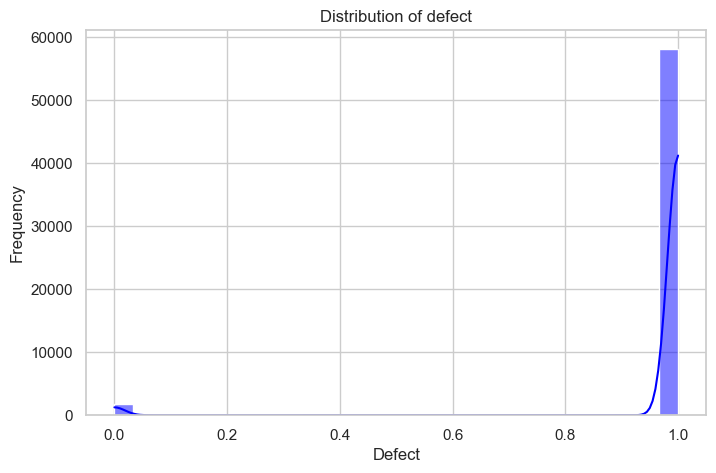

In [10]:
#distribution of the target variable
plt.figure(figsize=(8, 5))
sns.histplot(df_full['defect'], bins=30, kde=True, color='blue')
plt.title('Distribution of defect')
plt.xlabel('Defect')
plt.ylabel('Frequency')
plt.show()

In [11]:
print((df_full['defect'] == 0).sum())
print((df_full['defect'] == 1).sum())

1777
58223


In [12]:
df_non_defect = df_full[df_full['defect'] == 0]

df_defect_sample = df_full[df_full['defect'] == 1].sample(
    n=len(df_non_defect),
    random_state=42
)

df_balanced = pd.concat([df_non_defect, df_defect_sample])

df = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

df_unused = df_full.drop(df_balanced.index).reset_index(drop=True)

df

,lines_of_code,cyclomatic_complexity,num_functions,num_classes,comment_density,code_churn,developer_experience_years,num_developers,commit_frequency,bug_fix_commits,...,avg_function_length,depth_of_inheritance,response_for_class,coupling_between_objects,lack_of_cohesion,build_failures,static_analysis_warnings,security_vulnerabilities,performance_issues,defect
0,392,2,124,13,0.06,348,1,4,157,63,...,13,0,8,13,0.98,16,57,14,21,0
1,754,3,22,86,0.13,581,19,1,207,180,...,65,7,71,24,0.65,7,188,32,17,1
2,4057,20,79,73,0.50,759,6,4,299,98,...,53,5,8,48,0.80,8,213,6,12,1
3,1153,17,103,97,0.24,748,4,2,43,137,...,129,9,86,39,0.41,7,297,30,26,1
4,4967,36,181,96,0.25,833,9,9,61,0,...,79,8,60,19,0.50,11,51,10,18,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3549,480,19,29,15,0.31,349,8,10,141,159,...,113,8,52,5,0.40,12,55,31,4,0
3550,1480,20,87,56,0.09,596,13,6,168,185,...,44,6,16,6,0.36,12,13,46,20,0
3551,2474,13,112,89,0.12,976,4,2,215,144,...,40,3,73,6,0.51,10,20,24,24,0
3552,1153,27,167,9,0.37,102,0,14,69,195,...,103,7,55,34,0.21,10,237,16,10,1


In [13]:
print((df_unused['defect'] == 0).sum())
print((df_unused['defect'] == 1).sum())

0
56446


In [14]:
print((df['defect'] == 0).sum())
print((df['defect'] == 1).sum())

1777
1777


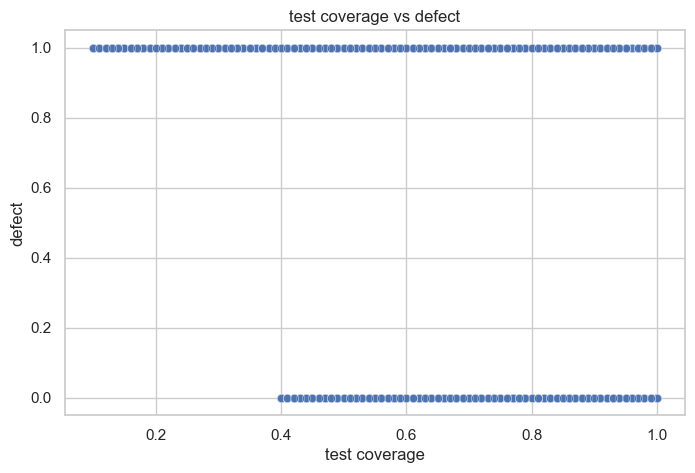

In [15]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='test_coverage', y='defect', alpha=0.3)
plt.title('test coverage vs defect')
plt.xlabel('test coverage')
plt.ylabel('defect')
plt.show()

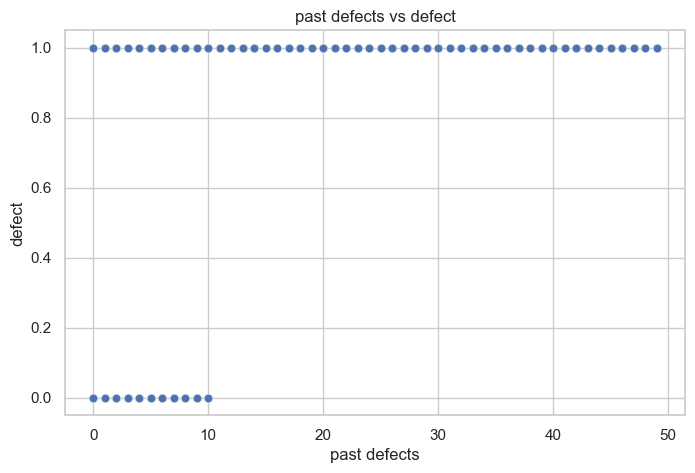

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='past_defects', y='defect', alpha=0.3)
plt.title('past defects vs defect')
plt.xlabel('past defects')
plt.ylabel('defect')
plt.show()

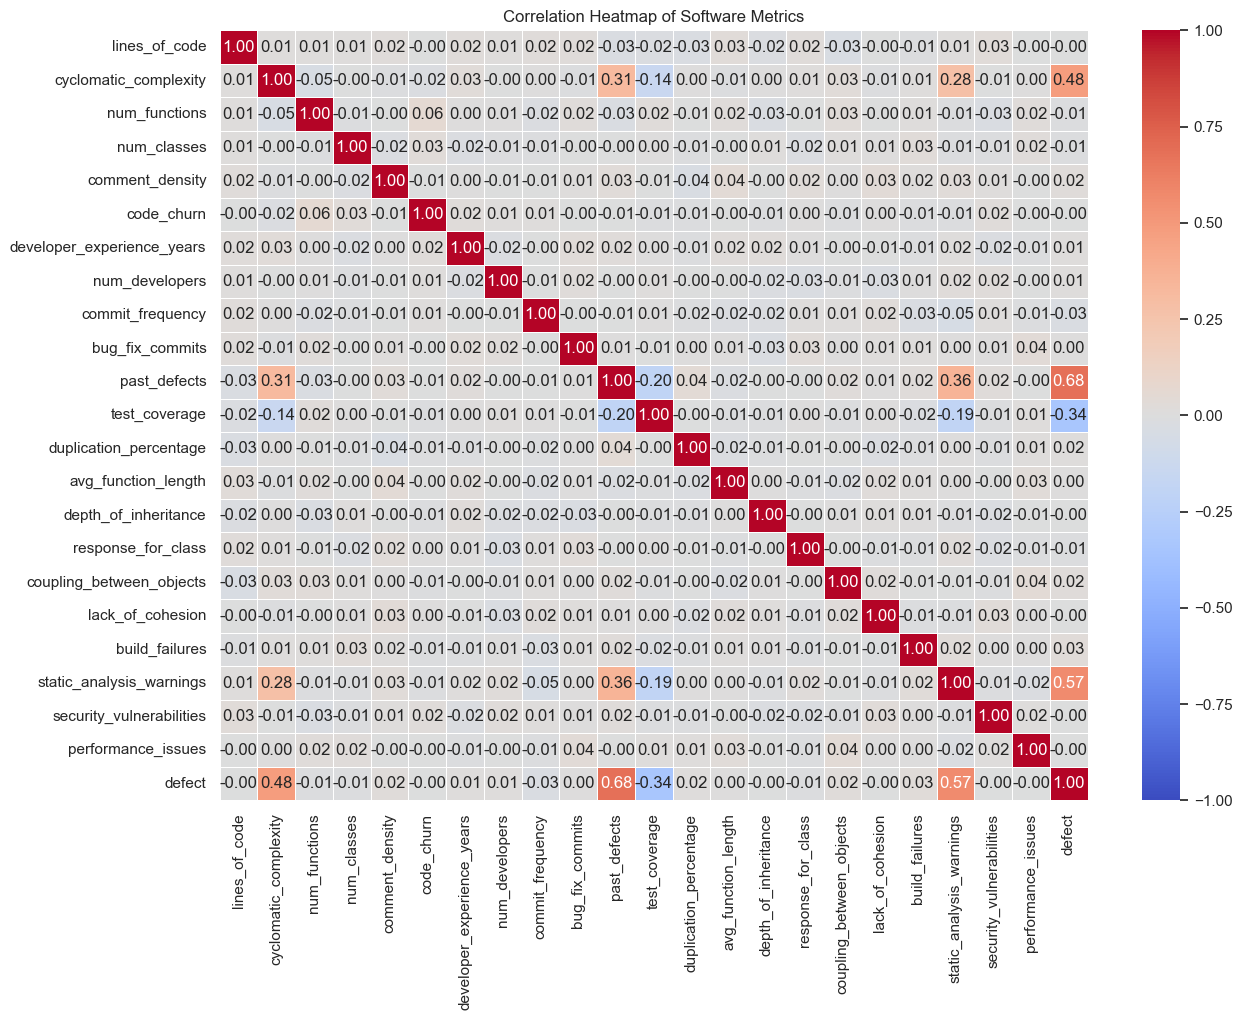

Correlation with defect:

defect                        1.000000
past_defects                  0.681163
static_analysis_warnings      0.565778
cyclomatic_complexity         0.479219
build_failures                0.029823
comment_density               0.023359
coupling_between_objects      0.020646
duplication_percentage        0.015241
num_developers                0.010069
developer_experience_years    0.009196
bug_fix_commits               0.004507
avg_function_length           0.000504
code_churn                   -0.000765
lack_of_cohesion             -0.001257
lines_of_code                -0.002705
security_vulnerabilities     -0.003100
performance_issues           -0.004481
depth_of_inheritance         -0.004535
num_functions                -0.010212
num_classes                  -0.011752
response_for_class           -0.013358
commit_frequency             -0.026874
test_coverage                -0.342167
Name: defect, dtype: float64


In [17]:
# Select only numerical columns for the correlation matrix
numerical_df = df.select_dtypes(include=[np.number])

# Compute the correlation matrix
corr_matrix = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap of Software Metrics')
plt.show()

# Isolate the correlations specifically with the target variable
print("Correlation with defect:\n")
print(corr_matrix['defect'].sort_values(ascending=False))

In [18]:
X = df.drop(columns=['defect'])
y = df['defect']

In [19]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42, stratify=y)
print(len(X_test))
print(len(X_train))

889
2665


In [20]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train,y_train)

RandomForestClassifier()

In [21]:
rf_preds = rf.predict(X_test)

cm = confusion_matrix(y_test, rf_preds)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[445   0]
 [  0 444]]


In [22]:
print("Accuracy :", accuracy_score(y_test, rf_preds))
print("Precision:", precision_score(y_test, rf_preds))
print("Recall   :", recall_score(y_test, rf_preds))
print("F1-score :", f1_score(y_test, rf_preds))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0


In [23]:
print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       445
           1       1.00      1.00      1.00       444

    accuracy                           1.00       889
   macro avg       1.00      1.00      1.00       889
weighted avg       1.00      1.00      1.00       889



In [24]:
importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance_df.head(10)

,feature,importance
10,past_defects,0.373253
19,static_analysis_warnings,0.238490
1,cyclomatic_complexity,0.200046
11,test_coverage,0.110574
0,lines_of_code,0.006506
13,avg_function_length,0.005379
5,code_churn,0.005364
8,commit_frequency,0.005163
9,bug_fix_commits,0.005108
2,num_functions,0.004642


In [25]:
result = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

perm_importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

perm_importance_df.head(10)

,feature,importance
10,past_defects,0.232396
19,static_analysis_warnings,0.169179
1,cyclomatic_complexity,0.132958
11,test_coverage,0.095501
2,num_functions,0.000000
0,lines_of_code,0.000000
5,code_churn,0.000000
4,comment_density,0.000000
3,num_classes,0.000000
6,developer_experience_years,0.000000


In [26]:
df_unused

,lines_of_code,cyclomatic_complexity,num_functions,num_classes,comment_density,code_churn,developer_experience_years,num_developers,commit_frequency,bug_fix_commits,...,avg_function_length,depth_of_inheritance,response_for_class,coupling_between_objects,lack_of_cohesion,build_failures,static_analysis_warnings,security_vulnerabilities,performance_issues,defect
0,910,12,7,79,0.59,539,19,4,23,7,...,70,1,54,27,0.06,3,20,31,21,1
1,3822,9,197,72,0.30,584,8,8,126,153,...,180,5,73,23,0.39,9,154,38,29,1
2,3142,20,99,92,0.11,593,0,6,272,177,...,152,5,9,31,0.08,7,425,22,6,1
3,516,39,52,79,0.18,81,12,14,16,0,...,159,9,23,12,0.44,2,339,24,12,1
4,4476,27,162,75,0.21,918,14,1,164,109,...,169,2,84,9,0.41,3,111,19,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56441,3521,4,45,93,0.49,742,0,4,237,0,...,186,9,43,18,0.41,12,215,29,1,1
56442,4286,26,194,79,0.17,878,16,12,179,74,...,86,4,59,45,0.62,3,4,31,4,1
56443,919,46,119,42,0.03,649,1,5,194,42,...,9,1,16,18,0.93,13,207,36,5,1
56444,3127,10,120,22,0.25,971,5,11,268,141,...,38,1,34,48,0.22,0,117,6,16,1


In [27]:
X_unused = df_unused.drop(columns=['defect'])
y_unused = df_unused['defect']

In [28]:
rf_preds = rf.predict(X_unused)

cm = confusion_matrix(y_unused, rf_preds)
print("Confusion Matrix:")
print(cm)

print("Accuracy :", accuracy_score(y_unused, rf_preds))
print("Precision:", precision_score(y_unused, rf_preds))
print("Recall   :", recall_score(y_unused, rf_preds))
print("F1-score :", f1_score(y_unused, rf_preds))

Confusion Matrix:
[[    0     0]
 [    8 56438]]
Accuracy : 0.9998582716224356
Precision: 1.0
Recall   : 0.9998582716224356
F1-score : 0.9999291307891287


In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=3)

In [31]:
knn_preds = knn.predict(X_test_scaled)

C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] A rendszer nem találja a megadott fájlt
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^

In [32]:
cm = confusion_matrix(y_test, knn_preds)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[432  13]
 [110 334]]


In [33]:
print("Accuracy :", accuracy_score(y_test, knn_preds))
print("Precision:", precision_score(y_test, knn_preds))
print("Recall   :", recall_score(y_test, knn_preds))
print("F1-score :", f1_score(y_test, knn_preds))

Accuracy : 0.8616422947131609
Precision: 0.962536023054755
Recall   : 0.7522522522522522
F1-score : 0.8445006321112516


In [34]:
knn_preds = knn.predict(X_unused)

cm = confusion_matrix(y_unused, knn_preds)
print("Confusion Matrix:")
print(cm)

print("Accuracy :", accuracy_score(y_unused, knn_preds))
print("Precision:", precision_score(y_unused, knn_preds))
print("Recall   :", recall_score(y_unused, knn_preds))
print("F1-score :", f1_score(y_unused, knn_preds))

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


Confusion Matrix:
[[    0     0]
 [ 1217 55229]]
Accuracy : 0.978439570563016
Precision: 1.0
Recall   : 0.978439570563016
F1-score : 0.9891023057980748
